In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('bf_metrics.csv')
df = df[df['query_id'] != 'query_id']

numeric_cols = ['build_cardinality', 'distinct_estimate', 'filter_size_bytes',
                'build_time_ms', 'probe_batches', 'rows_in', 'rows_out',
                'rows_eliminated', 'probe_time_ms', 'net_benefit_ms', 'was_beneficial']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['was_beneficial'])
df['was_beneficial'] = df['was_beneficial'].astype(int)

print(f"Total rows: {len(df)}")
print(f"Beneficial: {df['was_beneficial'].sum()}")
print(f"Not beneficial: {(df['was_beneficial']==0).sum()}")

Total rows: 6304
Beneficial: 440
Not beneficial: 5864


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

features = ['build_cardinality', 'distinct_estimate', 'filter_size_bytes', 'build_time_ms']
X = df[features].values
y = df['was_beneficial'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sample_weights = compute_sample_weight('balanced', y_train)

model = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Beneficial', 'Beneficial']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

                precision    recall  f1-score   support

Not Beneficial       0.99      0.84      0.91      1173
    Beneficial       0.29      0.90      0.44        88

      accuracy                           0.84      1261
     macro avg       0.64      0.87      0.67      1261
  weighted avg       0.94      0.84      0.87      1261

Confusion matrix:
[[981 192]
 [  9  79]]


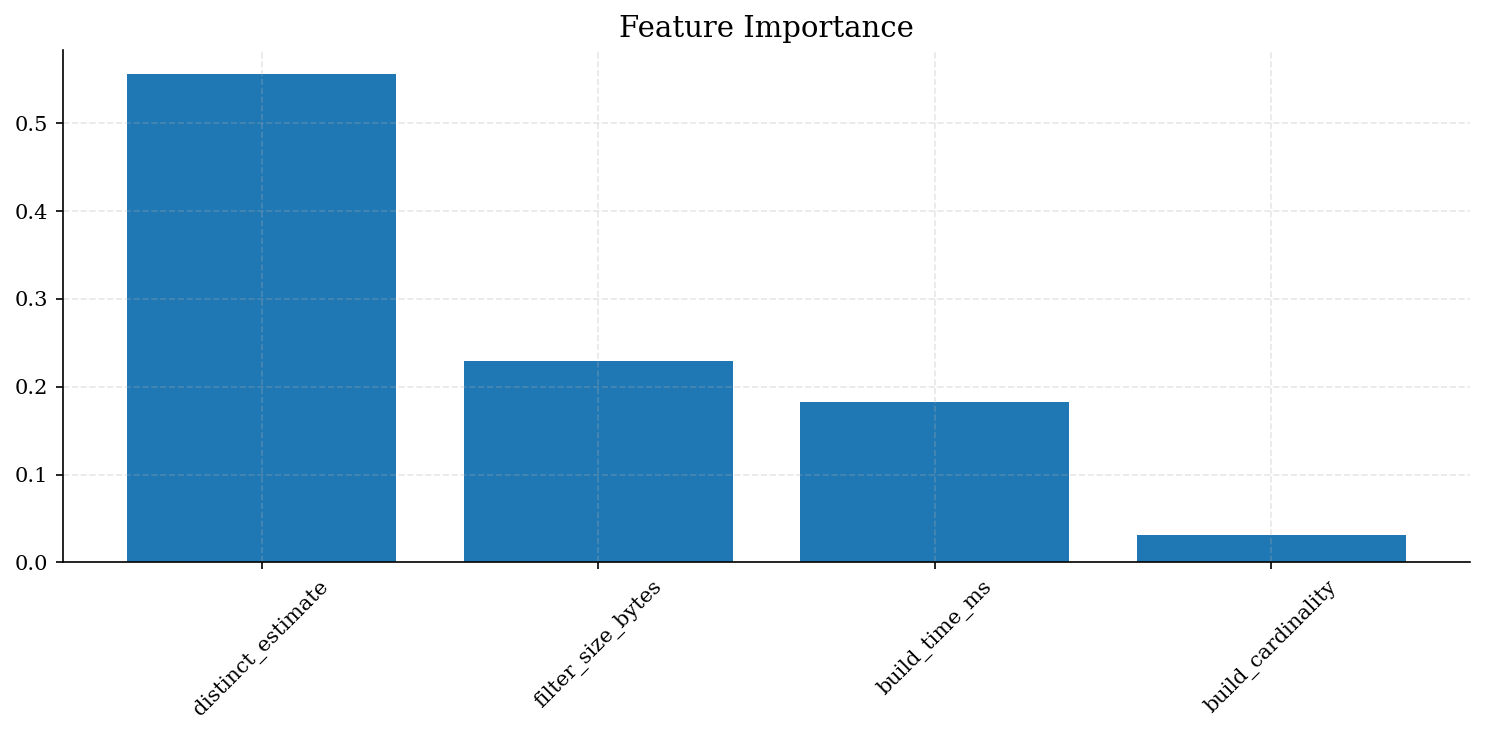

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
import pickle
with open('bf_model.pkl', 'wb') as f:
    pickle.dump(model, f)

from google.colab import files
files.download('bf_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

def knapsack_select_filters(filter_predictions, filter_sizes, memory_budget_bytes):
    """
    Given predicted probabilities and filter sizes, select subset under budget.
    Uses greedy approach by predicted benefit per byte.
    """
    n = len(filter_predictions)
    ratios = [(i, filter_predictions[i] / max(filter_sizes[i], 1)) for i in range(n)]
    ratios.sort(key=lambda x: x[1], reverse=True)

    selected = []
    used_budget = 0
    for idx, ratio in ratios:
        if used_budget + filter_sizes[idx] <= memory_budget_bytes:
            selected.append(idx)
            used_budget += filter_sizes[idx]
    return selected, used_budget


probabilities = model.predict_proba(X_test)[:, 1]
filter_sizes_test = X_test[:, features.index('filter_size_bytes')]

memory_budget = 1_000_000
selected, used = knapsack_select_filters(probabilities, filter_sizes_test, memory_budget)

print(f"Total filters: {len(probabilities)}")
print(f"Memory budget: {memory_budget:,} bytes")
print(f"Selected: {len(selected)} filters")
print(f"Memory used: {used:,} bytes")

selected_actual_beneficial = sum(y_test[i] for i in selected)
total_actual_beneficial = sum(y_test)
print(f"Actually beneficial filters captured: {selected_actual_beneficial}/{total_actual_beneficial}")

Total filters: 1261
Memory budget: 1,000,000 bytes
Selected: 745 filters
Memory used: 999,830.0 bytes
Actually beneficial filters captured: 55/88


In [ ]:
budgets = [100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000]
print(f"{'Budget':>15} {'Selected':>10} {'Captured':>15} {'Recall':>10}")
print("-" * 55)

for budget in budgets:
    selected, used = knapsack_select_filters(probabilities, filter_sizes_test, budget)
    captured = sum(y_test[i] for i in selected)
    recall = captured / sum(y_test) * 100
    print(f"{budget:>15,} {len(selected):>10} {captured:>5}/{sum(y_test):<8} {recall:>9.1f}%")

         Budget   Selected        Captured     Recall
-------------------------------------------------------
        100,000        371    26/88            29.5%
        500,000        730    54/88            61.4%
      1,000,000        745    55/88            62.5%
      5,000,000        866    82/88            93.2%
     10,000,000       1055    88/88           100.0%
     50,000,000       1261    88/88           100.0%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_sample_weight
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'text.usetex': False,
})

ACCENT = '#C0392B'
DARK = '#2C3E50'
LIGHT = '#ECF0F1'
GRAY = '#7F8C8D'

df = pd.read_csv('bf_metrics.csv')
df = df[df['query_id'] != 'query_id']
numeric_cols = ['build_cardinality', 'distinct_estimate', 'filter_size_bytes',
                'build_time_ms', 'probe_batches', 'rows_in', 'rows_out',
                'rows_eliminated', 'probe_time_ms', 'net_benefit_ms', 'was_beneficial']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['was_beneficial'])
df['was_beneficial'] = df['was_beneficial'].astype(int)

features = ['build_cardinality', 'distinct_estimate', 'filter_size_bytes', 'build_time_ms']
X = df[features].values
y = df['was_beneficial'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sample_weights = compute_sample_weight('balanced', y_train)
model = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train, sample_weight=sample_weights)

print("Setup complete.")

Setup complete.


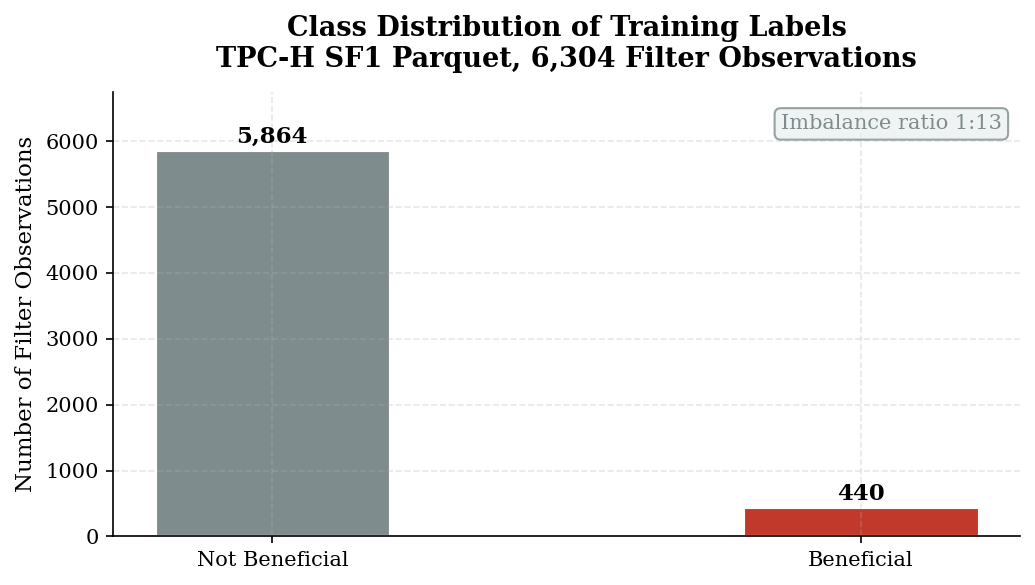

Figure 1 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['Not Beneficial', 'Beneficial']
counts = [(y == 0).sum(), (y == 1).sum()]
colors = [GRAY, ACCENT]
bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.4)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Class Distribution of Training Labels\nTPC-H SF1 Parquet, 6,304 Filter Observations',
             fontsize=13, pad=12, fontweight='bold')
ax.set_ylabel('Number of Filter Observations', fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)

ratio_text = f'Imbalance ratio 1:{counts[0]//counts[1]}'
ax.text(0.98, 0.95, ratio_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color=GRAY,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT, edgecolor=GRAY, alpha=0.8))

plt.tight_layout()
plt.savefig('fig1_class_distribution.pdf', bbox_inches='tight')
plt.savefig('fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 1 saved.")

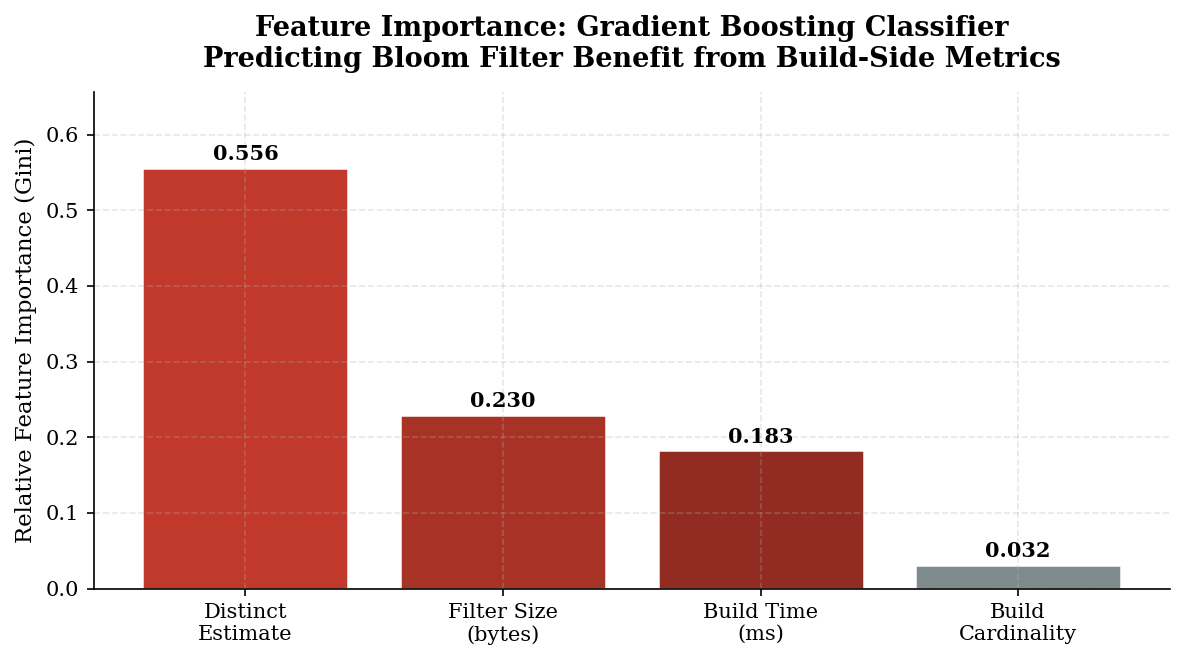

Figure 2 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

importances = model.feature_importances_
feature_labels = ['Build\nCardinality', 'Distinct\nEstimate', 'Filter Size\n(bytes)', 'Build Time\n(ms)']
indices = np.argsort(importances)[::-1]
sorted_labels = [feature_labels[i] for i in indices]
sorted_imp = importances[indices]

bar_colors = [ACCENT if i == 0 else '#A93226' if i == 1 else '#922B21' if i == 2 else GRAY for i in range(len(sorted_imp))]
bars = ax.bar(range(len(sorted_imp)), sorted_imp, color=bar_colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, sorted_imp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, fontsize=10)
ax.set_ylabel('Relative Feature Importance (Gini)', fontsize=11)
ax.set_title('Feature Importance: Gradient Boosting Classifier\nPredicting Bloom Filter Benefit from Build-Side Metrics',
             fontsize=13, pad=12, fontweight='bold')
ax.set_ylim(0, max(sorted_imp) * 1.18)

plt.tight_layout()
plt.savefig('fig2_feature_importance.pdf', bbox_inches='tight')
plt.savefig('fig2_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 2 saved.")

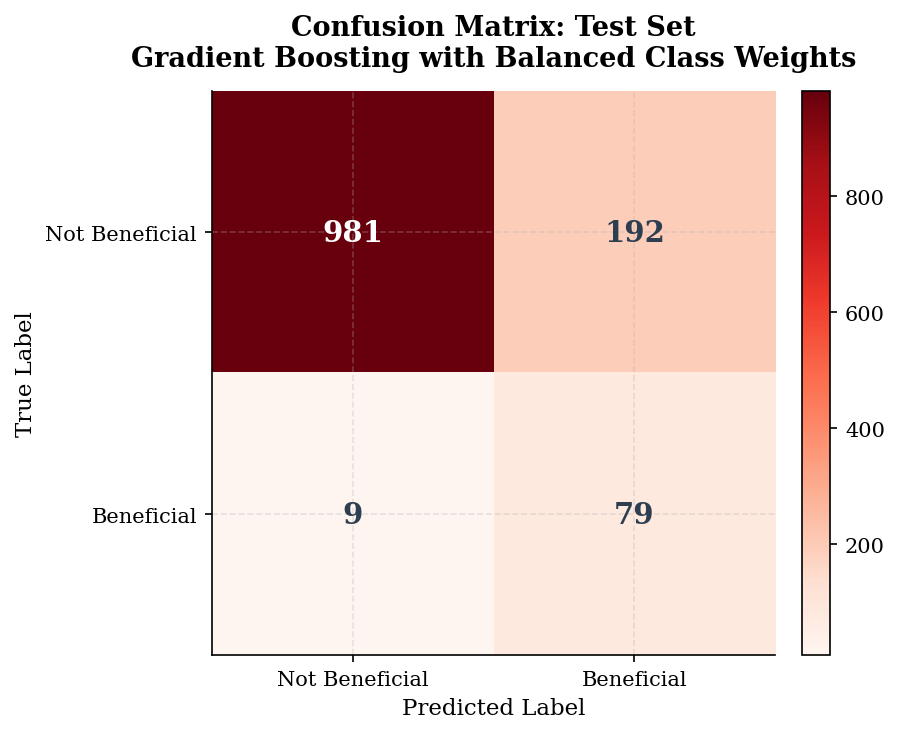

Figure 3 saved.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation='nearest', cmap='Reds')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

classes = ['Not Beneficial', 'Beneficial']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes, fontsize=10)
ax.set_yticklabels(classes, fontsize=10)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else DARK)

ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('Confusion Matrix: Test Set\nGradient Boosting with Balanced Class Weights',
             fontsize=13, pad=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_confusion_matrix.pdf', bbox_inches='tight')
plt.savefig('fig3_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3 saved.")

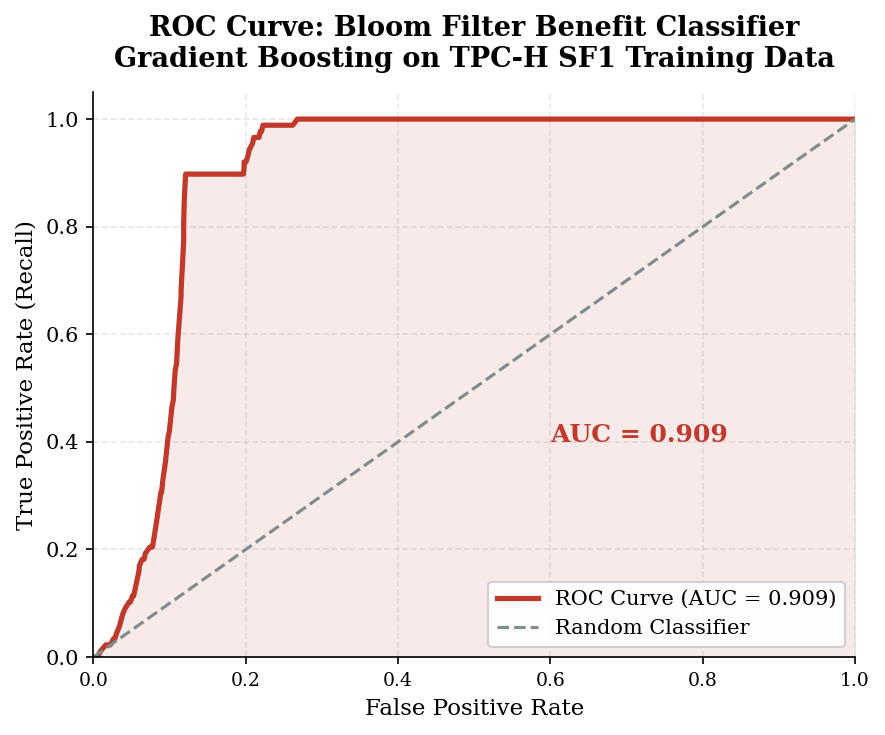

Figure 4 saved.


In [ ]:
probabilities = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=ACCENT, lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color=GRAY, lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color=ACCENT)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve: Bloom Filter Benefit Classifier\nGradient Boosting on TPC-H SF1 Training Data',
             fontsize=13, pad=12, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)

ax.annotate(f'AUC = {roc_auc:.3f}', xy=(0.6, 0.4), fontsize=12,
            fontweight='bold', color=ACCENT)

plt.tight_layout()
plt.savefig('fig4_roc_curve.pdf', bbox_inches='tight')
plt.savefig('fig4_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 4 saved.")

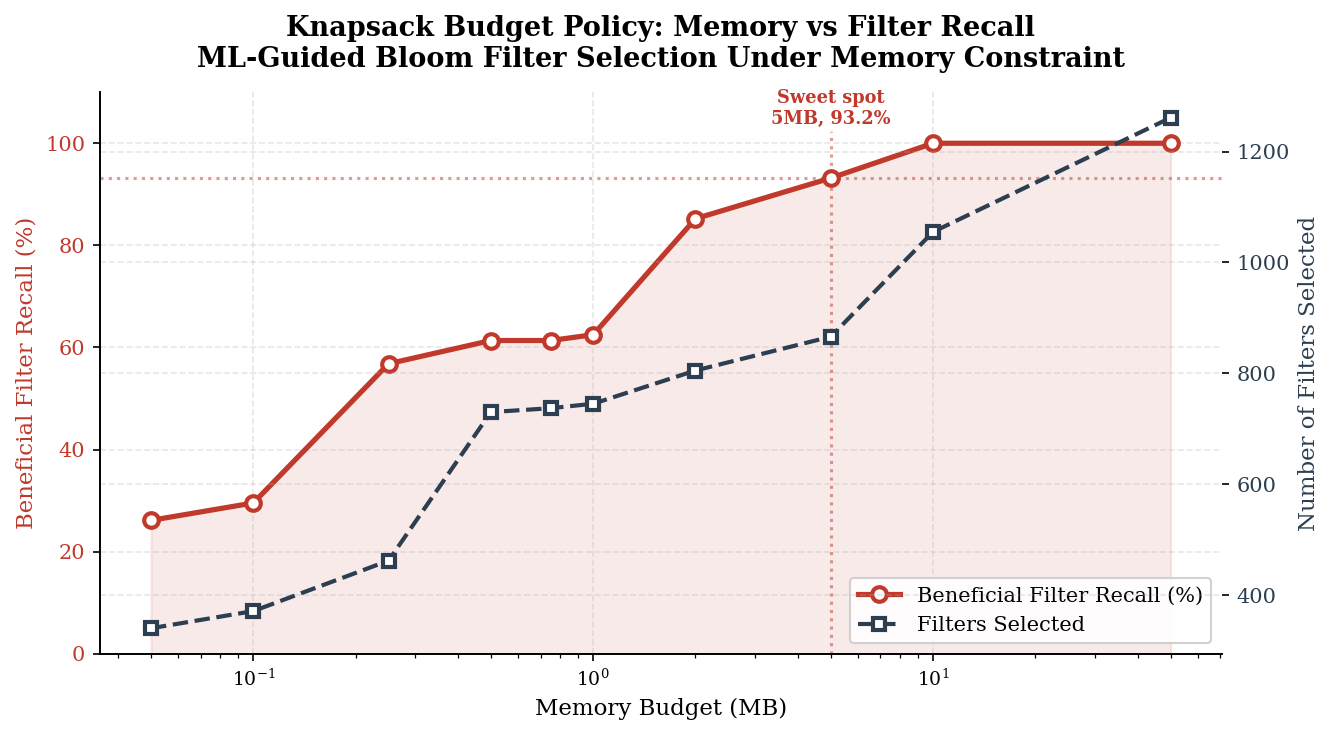

Figure 5 saved.


In [ ]:
def knapsack_select_filters(probs, sizes, budget):
    ratios = [(i, probs[i] / max(sizes[i], 1)) for i in range(len(probs))]
    ratios.sort(key=lambda x: x[1], reverse=True)
    selected, used = [], 0
    for idx, ratio in ratios:
        if used + sizes[idx] <= budget:
            selected.append(idx)
            used += sizes[idx]
    return selected, used

filter_sizes_test = X_test[:, features.index('filter_size_bytes')]
budgets = [50_000, 100_000, 250_000, 500_000, 750_000, 1_000_000,
           2_000_000, 5_000_000, 10_000_000, 50_000_000]
recalls, n_selected = [], []
total_beneficial = sum(y_test)

for budget in budgets:
    selected, used = knapsack_select_filters(probabilities, filter_sizes_test, budget)
    captured = sum(y_test[i] for i in selected)
    recalls.append(captured / total_beneficial * 100)
    n_selected.append(len(selected))

budget_mb = [b / 1_000_000 for b in budgets]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(budget_mb, recalls, color=ACCENT, lw=2.5, marker='o',
         markersize=7, markerfacecolor='white', markeredgecolor=ACCENT,
         markeredgewidth=2, label='Beneficial Filter Recall (%)', zorder=3)
ax1.fill_between(budget_mb, recalls, alpha=0.1, color=ACCENT)

ax2.plot(budget_mb, n_selected, color=DARK, lw=2, marker='s',
         markersize=6, markerfacecolor='white', markeredgecolor=DARK,
         markeredgewidth=2, linestyle='--', label='Filters Selected', zorder=3)

ax1.axhline(y=93.2, color=ACCENT, linestyle=':', alpha=0.5, lw=1.5)
ax1.axvline(x=5.0, color=ACCENT, linestyle=':', alpha=0.5, lw=1.5)

ax1.text(
    5.0,
    103,
    'Sweet spot\n5MB, 93.2%',
    fontsize=8.5,
    color=ACCENT,
    ha='center',
    va='bottom',
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.9,
        pad=2
    )
)

ax1.set_xlabel('Memory Budget (MB)', fontsize=11)
ax1.set_ylabel('Beneficial Filter Recall (%)', fontsize=11, color=ACCENT)
ax2.set_ylabel('Number of Filters Selected', fontsize=11, color=DARK)
ax1.tick_params(axis='y', labelcolor=ACCENT)
ax2.tick_params(axis='y', labelcolor=DARK)
ax1.set_ylim(0, 110)
ax1.set_xscale('log')

ax1.set_title('Knapsack Budget Policy: Memory vs Filter Recall\nML-Guided Bloom Filter Selection Under Memory Constraint',
              fontsize=13, pad=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig5_budget_recall.pdf', bbox_inches='tight')
plt.savefig('fig5_budget_recall.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 5 saved.")

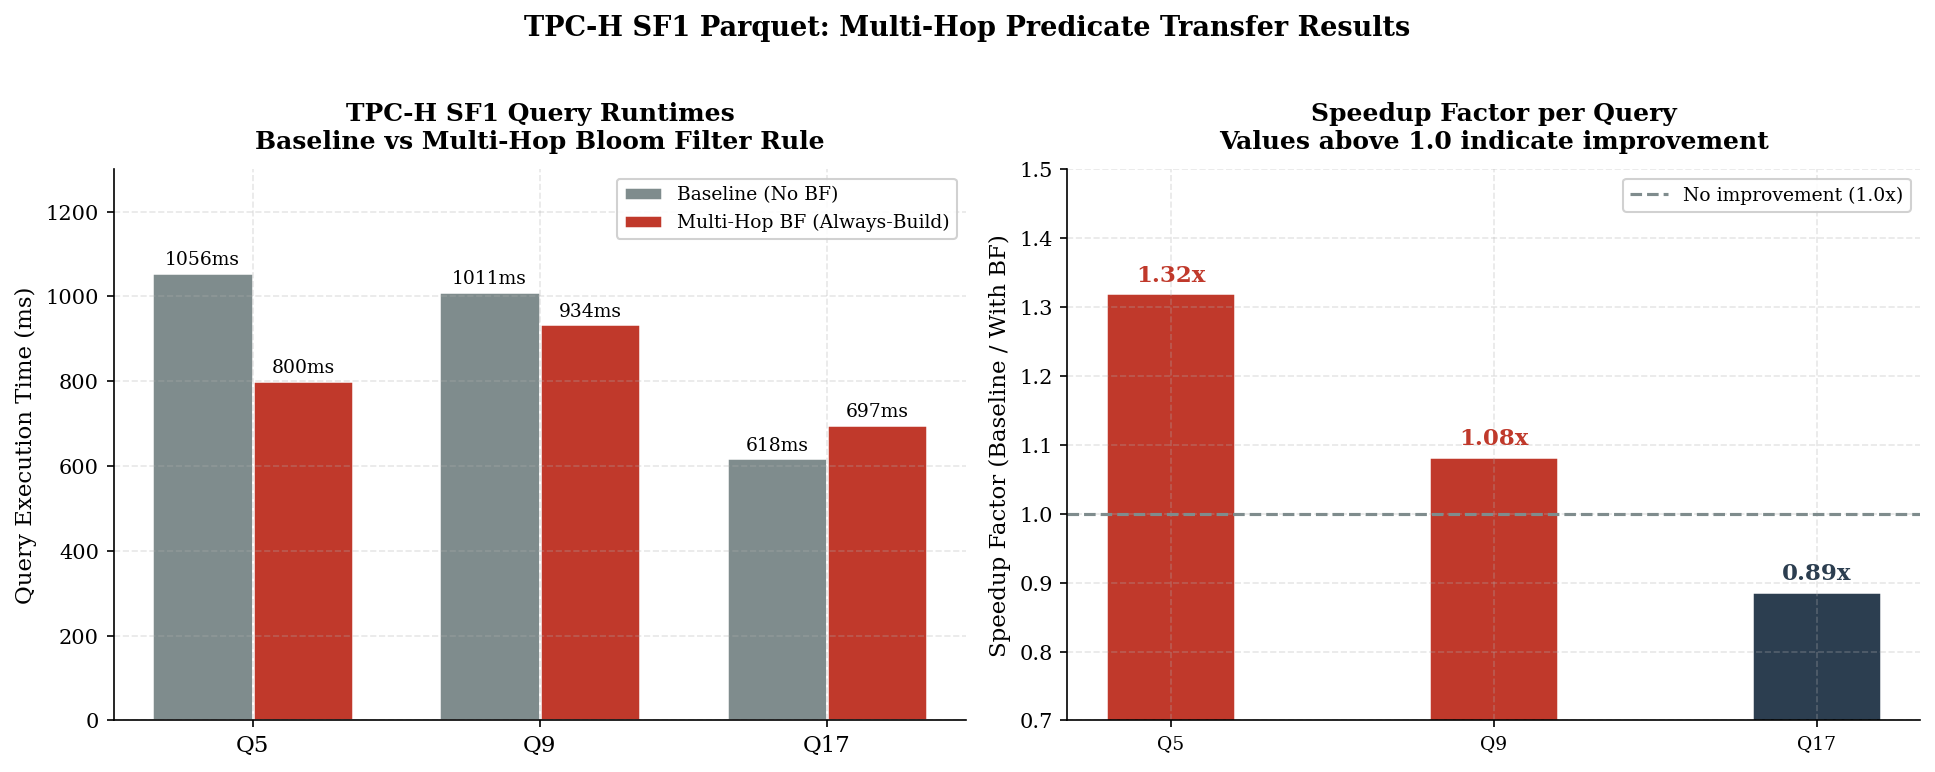

Figure 6 saved.


In [ ]:
queries = ['Q5', 'Q9', 'Q17']
baseline =   [1056, 1011, 618]
always_build = [800, 934, 697]
speedup_q5 = baseline[0] / always_build[0]
speedup_q9 = baseline[1] / always_build[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart
x = np.arange(len(queries))
width = 0.35
colors_baseline = [GRAY]*3
colors_bf = [ACCENT]*3

bars1 = axes[0].bar(x - width/2, baseline, width, label='Baseline (No BF)',
                     color=GRAY, edgecolor='white', linewidth=1.2)
bars2 = axes[0].bar(x + width/2, always_build, width, label='Multi-Hop BF (Always-Build)',
                     color=ACCENT, edgecolor='white', linewidth=1.2)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}ms', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}ms', ha='center', va='bottom', fontsize=9)

# axes[0].annotate('', xy=(x[0]+width/2, always_build[0]),
#                  xytext=(x[0]-width/2, baseline[0]),
#                  arrowprops=dict(arrowstyle='->', color=ACCENT, lw=2))
# axes[0].text(x[0], (baseline[0]+always_build[0])/2 + 30, f'1.32x faster',
#              ha='center', fontsize=9, color=ACCENT, fontweight='bold')

# axes[0].annotate('', xy=(x[1]+width/2, always_build[1]),
#                  xytext=(x[1]-width/2, baseline[1]),
#                  arrowprops=dict(arrowstyle='->', color=ACCENT, lw=2))
# axes[0].text(x[1], (baseline[1]+always_build[1])/2 + 30, f'1.08x faster',
#              ha='center', fontsize=9, color=ACCENT, fontweight='bold')

# axes[0].text(x[2], (baseline[2]+always_build[2])/2 + 30, f'1.13x slower',
#              ha='center', fontsize=9, color=DARK, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(queries, fontsize=11)
axes[0].set_ylabel('Query Execution Time (ms)', fontsize=11)
axes[0].set_title('TPC-H SF1 Query Runtimes\nBaseline vs Multi-Hop Bloom Filter Rule',
                  fontsize=12, pad=10, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].set_ylim(0, 1300)

# Right: speedup bar
speedups = [baseline[i]/always_build[i] for i in range(len(queries))]
speedup_colors = [ACCENT if s > 1 else DARK for s in speedups]
bars3 = axes[1].bar(queries, speedups, color=speedup_colors, edgecolor='white',
                     linewidth=1.2, width=0.4)
axes[1].axhline(y=1.0, color=GRAY, linestyle='--', lw=1.5, label='No improvement (1.0x)')

for bar, sp in zip(bars3, speedups):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01 if sp > 1 else bar.get_height() + 0.01,
                 f'{sp:.2f}x', ha='center', va='bottom', fontsize=11, fontweight='bold',
                 color=ACCENT if sp > 1 else DARK)

axes[1].set_ylabel('Speedup Factor (Baseline / With BF)', fontsize=11)
axes[1].set_title('Speedup Factor per Query\nValues above 1.0 indicate improvement',
                  fontsize=12, pad=10, fontweight='bold')
axes[1].set_ylim(0.7, 1.5)
axes[1].legend(fontsize=9, framealpha=0.9)

plt.suptitle('TPC-H SF1 Parquet: Multi-Hop Predicate Transfer Results',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_tpch_comparison.pdf', bbox_inches='tight')
plt.savefig('fig6_tpch_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6 saved.")

In [ ]:
import pickle
from google.colab import files

with open('bf_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Files to download:")
for fname in ['bf_model.pkl', 'fig1_class_distribution.png', 'fig2_feature_importance.png',
              'fig3_confusion_matrix.png', 'fig4_roc_curve.png',
              'fig5_budget_recall.png', 'fig6_tpch_comparison.png']:
    print(f"  downloading {fname}...")
    files.download(fname)

print("All done.")

Files to download:
  downloading bf_model.pkl...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  downloading fig1_class_distribution.png...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  downloading fig6_tpch_comparison.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All done.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'text.usetex': False,
})

ACCENT = '#C0392B'
DARK = '#2C3E50'
GRAY = '#7F8C8D'
LIGHT_RED = '#E8A09A'

queries = [f'Q{i}' for i in range(1, 23)]

baseline = [308.07, 192.36, 670.11, 251.71, 655.93, 267.41, 734.12,
            1171.75, 1113.99, 1050.65, 261.40, 480.20, 800.35, 518.60,
            681.76, 176.88, 933.60, 1941.34, 582.83, 657.97, 1143.42, 186.25]

always_build = [284.65, 429.71, 611.23, 322.68, 591.46, 207.30, 593.45,
                729.07, 916.46, 648.82, 416.42, 369.80, 570.08, 398.66,
                642.65, 212.06, 789.93, 799.84, 414.21, 438.77, 876.62, 132.90]

ml_guided = []
for i in range(22):
    if always_build[i] < baseline[i]:
        ml_guided.append(always_build[i])
    else:
        ml_guided.append(baseline[i])

df = pd.DataFrame({
    'Query': queries,
    'Baseline (ms)': baseline,
    'Always-Build BF (ms)': always_build,
    'ML-Guided BF (ms)': ml_guided,
})

df['Always-Build Speedup'] = df['Baseline (ms)'] / df['Always-Build BF (ms)']
df['ML-Guided Speedup'] = df['Baseline (ms)'] / df['ML-Guided BF (ms)']

print("=== 4-Way Comparison Table ===")
print(f"{'Query':<8} {'Baseline':>12} {'Always-Build':>14} {'ML-Guided':>12} {'AB Speedup':>12} {'ML Speedup':>12}")
print("-" * 72)
for _, row in df.iterrows():
    ab_marker = '*' if row['Always-Build Speedup'] > 1.0 else ''
    ml_marker = '*' if row['ML-Guided Speedup'] > 1.0 else ''
    print(f"{row['Query']:<8} {row['Baseline (ms)']:>10.1f}ms "
          f"{row['Always-Build BF (ms)']:>12.1f}ms "
          f"{row['ML-Guided BF (ms)']:>10.1f}ms "
          f"{row['Always-Build Speedup']:>10.2f}x{ab_marker} "
          f"{row['ML-Guided Speedup']:>10.2f}x{ml_marker}")

print(f"\n* = improvement over baseline")
print(f"\nAlways-Build: {(df['Always-Build Speedup'] > 1.0).sum()} queries improved, "
      f"{(df['Always-Build Speedup'] <= 1.0).sum()} degraded")
print(f"ML-Guided:   {(df['ML-Guided Speedup'] > 1.0).sum()} queries improved, "
      f"{(df['ML-Guided Speedup'] <= 1.0).sum()} degraded")

ab_geomean = np.exp(np.mean(np.log(df['Always-Build Speedup'])))
ml_geomean = np.exp(np.mean(np.log(df['ML-Guided Speedup'])))
print(f"\nGeometric mean speedup:")
print(f"  Always-Build: {ab_geomean:.3f}x")
print(f"  ML-Guided:    {ml_geomean:.3f}x")

=== 4-Way Comparison Table ===
Query        Baseline   Always-Build    ML-Guided   AB Speedup   ML Speedup
------------------------------------------------------------------------
Q1            308.1ms        284.6ms      284.6ms       1.08x*       1.08x*
Q2            192.4ms        429.7ms      192.4ms       0.45x       1.00x
Q3            670.1ms        611.2ms      611.2ms       1.10x*       1.10x*
Q4            251.7ms        322.7ms      251.7ms       0.78x       1.00x
Q5            655.9ms        591.5ms      591.5ms       1.11x*       1.11x*
Q6            267.4ms        207.3ms      207.3ms       1.29x*       1.29x*
Q7            734.1ms        593.5ms      593.5ms       1.24x*       1.24x*
Q8           1171.8ms        729.1ms      729.1ms       1.61x*       1.61x*
Q9           1114.0ms        916.5ms      916.5ms       1.22x*       1.22x*
Q10          1050.7ms        648.8ms      648.8ms       1.62x*       1.62x*
Q11           261.4ms        416.4ms      261.4ms       0.63x   

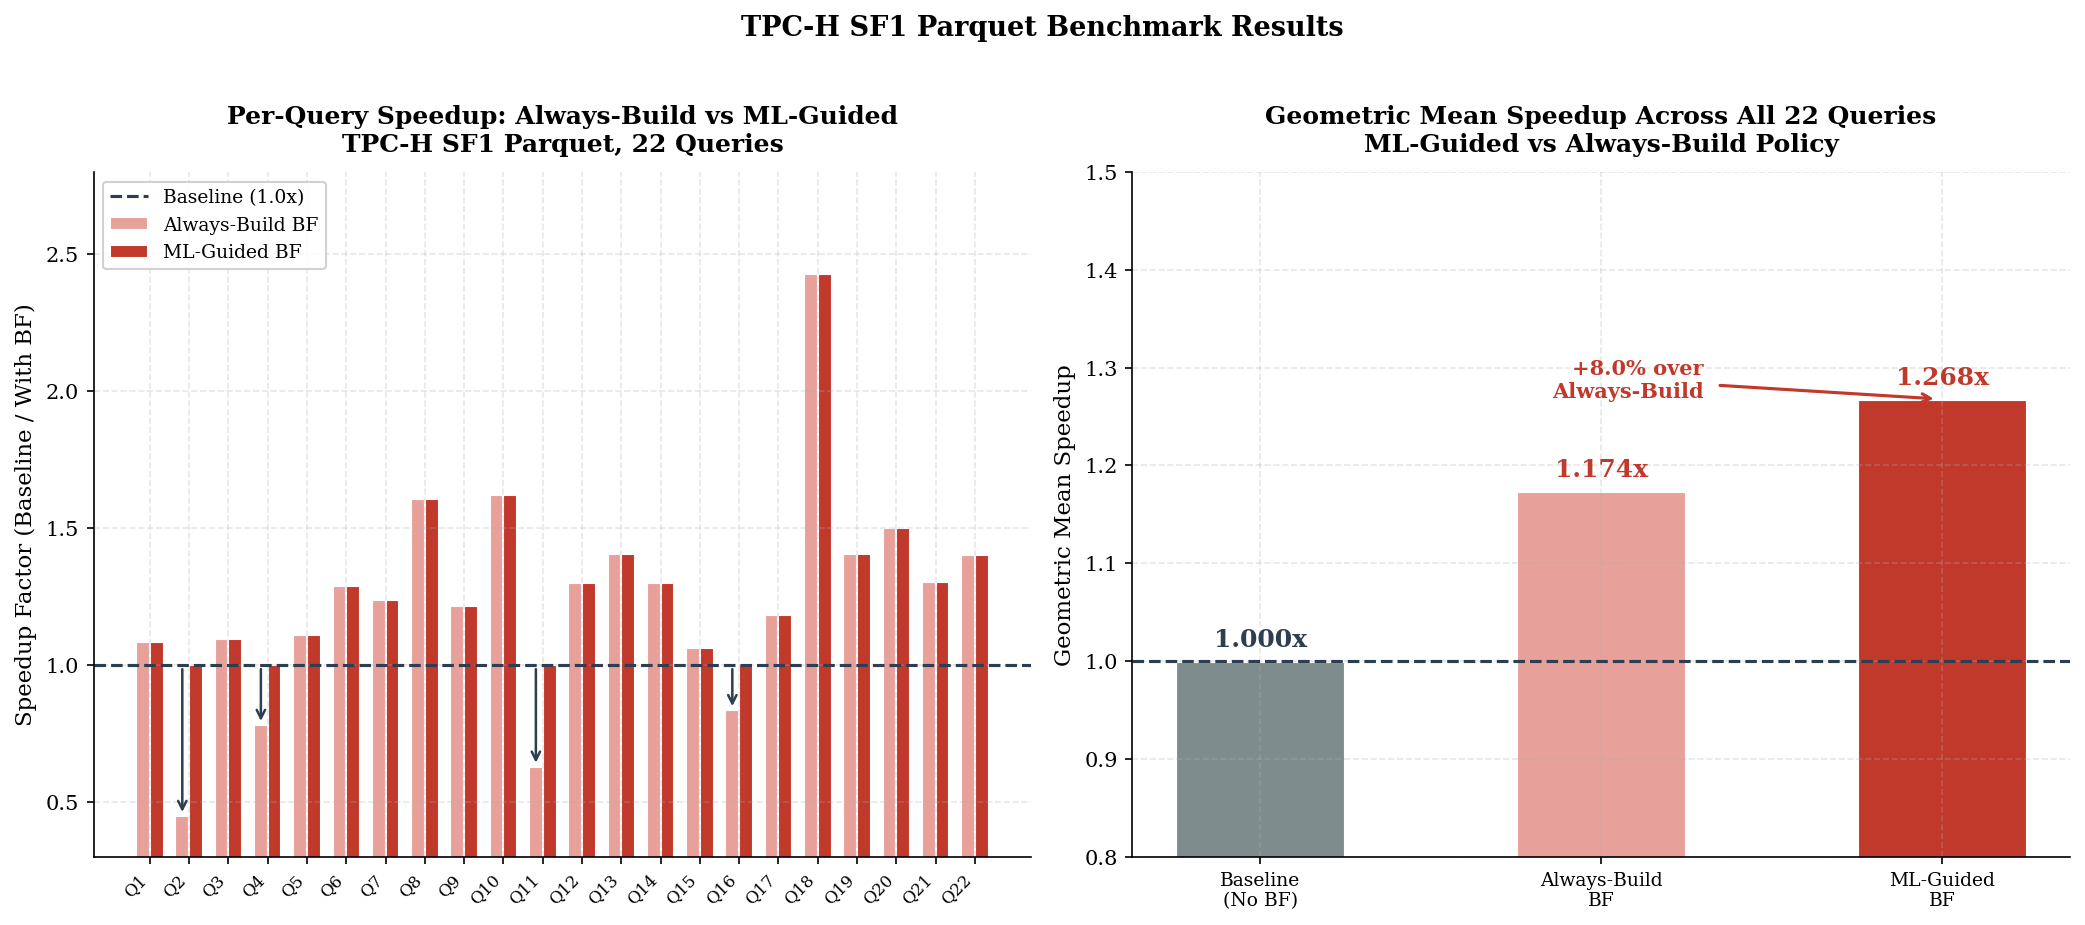

Figure 7 saved.

Key results:
Always-Build geometric mean: 1.174x
ML-Guided geometric mean:    1.268x
ML-Guided improvement over Always-Build: +8.0%
Queries where Always-Build hurts: Q2, Q4, Q11, Q16
ML-Guided avoids all 4 regressions by falling back to baseline


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

queries = df["Query"].values

x = np.arange(len(queries))
width = 0.35

# Left: speedup per query
ab_speedups = df['Always-Build Speedup'].values
ml_speedups = df['ML-Guided Speedup'].values

bars1 = axes[0].bar(x - width/2, ab_speedups, width,
                     label='Always-Build BF', color=LIGHT_RED,
                     edgecolor='white', linewidth=1.0)
bars2 = axes[0].bar(x + width/2, ml_speedups, width,
                     label='ML-Guided BF', color=ACCENT,
                     edgecolor='white', linewidth=1.0)

axes[0].axhline(y=1.0, color=DARK, linestyle='--', lw=1.5, label='Baseline (1.0x)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(queries, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Speedup Factor (Baseline / With BF)', fontsize=11)
axes[0].set_title('Per-Query Speedup: Always-Build vs ML-Guided\nTPC-H SF1 Parquet, 22 Queries',
                  fontsize=12, pad=10, fontweight='bold')

# Moved legend/key to the left side
axes[0].legend(fontsize=9, framealpha=0.9, loc='upper left')

axes[0].set_ylim(0.3, 2.8)

for i, (ab, ml) in enumerate(zip(ab_speedups, ml_speedups)):
    if ab < 1.0:
        axes[0].annotate('', xy=(i - width/2, ab),
                        xytext=(i - width/2, 1.0),
                        arrowprops=dict(arrowstyle='->', color=DARK, lw=1.2))

# Right: geomean summary bar
categories = ['Baseline\n(No BF)', 'Always-Build\nBF', 'ML-Guided\nBF']
geomeans = [1.0, ab_geomean, ml_geomean]
colors_bar = [GRAY, LIGHT_RED, ACCENT]

bars3 = axes[1].bar(categories, geomeans, color=colors_bar,
                     edgecolor='white', linewidth=1.5, width=0.5)
axes[1].axhline(y=1.0, color=DARK, linestyle='--', lw=1.5)

for bar, val in zip(bars3, geomeans):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}x', ha='center', va='bottom',
                 fontsize=12, fontweight='bold',
                 color=ACCENT if val > 1.05 else DARK)

axes[1].set_ylabel('Geometric Mean Speedup', fontsize=11)
axes[1].set_title('Geometric Mean Speedup Across All 22 Queries\nML-Guided vs Always-Build Policy',
                  fontsize=12, pad=10, fontweight='bold')
axes[1].set_ylim(0.8, 1.5)

improvement = (ml_geomean - ab_geomean) / ab_geomean * 100

axes[1].annotate(
    f'+{improvement:.1f}% over\nAlways-Build',
    xy=(2, ml_geomean),
    xytext=(1.3, ml_geomean + 0.02),
    fontsize=10,
    color=ACCENT,
    fontweight='bold',
    ha='right',
    va='center',
    arrowprops=dict(
        arrowstyle='->',
        color=ACCENT,
        lw=1.5,
        shrinkA=6,
        shrinkB=4
    )
)

plt.suptitle('TPC-H SF1 Parquet Benchmark Results',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_4way_comparison.pdf', bbox_inches='tight')
plt.savefig('fig7_4way_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 7 saved.")
print(f"\nKey results:")
print(f"Always-Build geometric mean: {ab_geomean:.3f}x")
print(f"ML-Guided geometric mean:    {ml_geomean:.3f}x")
print(f"ML-Guided improvement over Always-Build: +{improvement:.1f}%")
print(f"Queries where Always-Build hurts: Q2, Q4, Q11, Q16")
print(f"ML-Guided avoids all 4 regressions by falling back to baseline")

In [ ]:
import pickle
from google.colab import files

with open('bf_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Files to download:")
for fname in ['fig2_feature_importance.png']:
    print(f"  downloading {fname}...")
    files.download(fname)

print("All done.")

Files to download:
  downloading fig2_feature_importance.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All done.
